These are the findings of the following program

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import f1_score
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import time
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.svm import SVC
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Flatten
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

In [13]:
photos_csv = r"C:\Users\Gaurav\Downloads\photos.csv"
photos_folder = r"D:\Dataset\photos" 
# Load dataset
df = pd.read_csv(photos_csv)

In [15]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


In [17]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue", "orange", "yellow"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)
        
        
    print("class_count : ", class_counts)
    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in Traget ")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

class_count :  label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


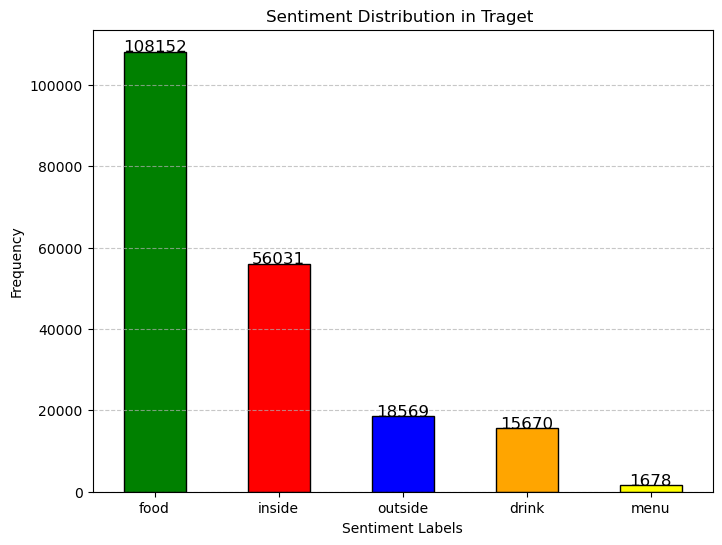

In [19]:
bar_plot(df['label'])

In [21]:
# Separate majority and minority classes
df_majority_food = df[df['label'] == 'food']
df_majority_inside = df[df['label'] == 'inside']
df_majority_outside = df[df['label'] == 'outside']
df_majority_drink = df[df['label'] == 'drink']
df_minority_menu = df[df['label'] == 'menu']

# Undersample majority classes to 600 samples each
df_majority_food_downsampled = resample(df_majority_food, replace=False, n_samples=300, random_state=42)
df_majority_inside_downsampled = resample(df_majority_inside, replace=False, n_samples=300, random_state=42)
df_majority_outside_downsampled = resample(df_majority_outside, replace=False, n_samples=300, random_state=42)
df_majority_drink_downsampled = resample(df_majority_drink, replace=False, n_samples=300, random_state=42)

# Oversample minority class to 600 samples
df_minority_menu_upsampled = resample(df_minority_menu, replace=True, n_samples=300, random_state=42)

# Combine all classes into a balanced DataFrame
df_balanced = pd.concat([df_majority_food_downsampled, df_majority_inside_downsampled, df_majority_outside_downsampled, df_majority_drink_downsampled, df_minority_menu_upsampled])

# Shuffle the DataFrame
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [23]:
df_balanced

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
...,...,...
1495,b2Z_mH6elUbFfZ__rFmxWg,drink
1496,Hja-ujyebg1J0xyOzeaY_w,menu
1497,JLe7-8DzxieeiOHn-m1r5Q,outside
1498,FIw7ce992NJheBr9qEFHCA,menu


class_count :  label
drink      300
menu       300
inside     300
outside    300
food       300
Name: count, dtype: int64


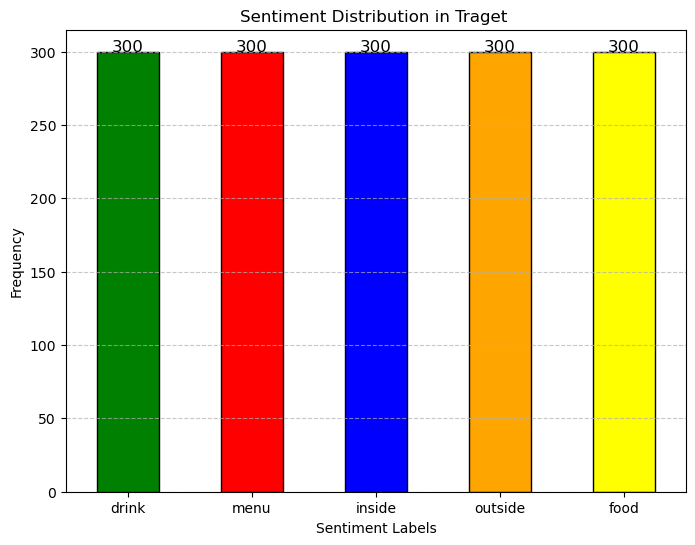

In [25]:
bar_plot(df_balanced['label'])

In [27]:
df = df_balanced

In [29]:
# Build a dictionary to map photo_id to the image file paths
photo_id_to_path = {}
for file in os.listdir(photos_folder):
    # Assuming the photo_id is in the file name (e.g., photo_id.jpg)
    photo_id = file.split('.')[0] # Adjust based on your file naming convention
    photo_id_to_path[photo_id] = os.path.join(photos_folder, file)

In [38]:
# Open the image
img = Image.open("D:\Dataset\photos\__02nEL2xViYvZihvV4_hw.jpg")

# Get the image size (width, height)
width, height = img.size
print(f"Width: {width}, Height: {height}")

Width: 400, Height: 400


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Gaurav\AppData\Local\Temp\ipykernel_35808\3232345269.py:2: SyntaxWarning: invalid escape sequence '\D'
  img = Image.open("D:\Dataset\photos\__02nEL2xViYvZihvV4_hw.jpg")


In [40]:
# Function to preprocess images (resize to 224x224 and normalize)
def preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        return img_array / 255.0  # Normalize the image
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Image path: {img_path}")
        return None

# Preprocess images for each photo_id
x_images = []
y_labels = []

for _, row in df.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    
    # Get the image path based on the photo_id
    img_path = photo_id_to_path.get(photo_id)
    
    if img_path:
        # Preprocess the image
        img = preprocess_image(img_path)
        if(img is not None) :
            x_images.append(img)
            y_labels.append(label)

# Convert lists to numpy arrays for further processing
print(len(x_images))

x_images = np.array(x_images)

print(x_images)
print(y_labels)


print("\nShape of the image array: ", x_images.shape)
print("length of target: ", len(y_labels))

Error occurred: cannot identify image file <_io.BytesIO object at 0x000001A509791CB0>
Image path: D:\Dataset\photos\l_rMdwgrvjm2PyHyXBcBTw.jpg
1393
[[[[0.9529412  0.9529412  0.9607843 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.69411767 0.8117647  0.9137255 ]
   [0.7607843  0.8627451  0.9529412 ]
   [0.78431374 0.88235295 0.96862745]]

  [[0.95686275 0.95686275 0.9647059 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.8509804  0.9372549  1.        ]
   [0.8745098  0.95686275 1.        ]
   [0.8862745  0.9607843  1.        ]]

  [[0.9607843  0.9607843  0.96862745]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.89411765 0.95686275 1.        ]
   [0.8980392  0.9529412  0.99607843]
   [0.89411765 0.9411765  0.9882353 ]]

  ...

  [[0.5137255  0.41960785 0.37254903]
   [0.49803922 0.39607844 0.3372549 ]
   [0.40784314 0.30980393 0.22352941]
   ...
   [0.4274509

In [41]:
label_mapping = {'food' : 0, 'inside' : 1, 'outside' : 2, 'drink' : 3, 'menu' : 4}
reverse_label_mapping = {0 : 'food',1 : 'inside',2 : 'outside',3 : 'drink',4 : 'menu'}

In [44]:
# Map the labels using the custom dictionary
y = np.array([label_mapping[label] for label in y_labels])

# Flatten the images
x = x_images.reshape(x_images.shape[0], -1)

print("Shape of the image array: ",x.shape)
print("Shape of the target array: ",y.shape)

print(y[:100])

Shape of the image array:  (1393, 150528)
Shape of the target array:  (1393,)
[3 4 1 1 1 2 3 2 4 2 4 2 4 0 4 4 2 1 0 3 3 3 4 4 1 4 4 4 3 2 4 3 0 1 1 1 3
 4 1 4 2 3 1 1 2 3 2 1 3 4 2 0 1 1 3 2 1 0 2 1 1 4 0 1 2 2 0 2 4 2 1 1 3 3
 0 0 2 2 0 2 3 2 3 3 0 0 4 3 1 1 0 3 1 3 2 3 0 0 3 0]


In [46]:
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

# Apply EfficientNet preprocessing to the entire batch of images
preprocessed_images = effnet_preprocess(x_images)

In [48]:
x_train, x_test, y_train, y_test = train_test_split(preprocessed_images, y, test_size=0.2, random_state=42)
print("Shape of x_train: ", x_train.shape)  # Should print (num_samples, 224, 224, 3)
print("Shape of y_train: ", y_train.shape)
print("Shape of x_test: ", x_test.shape)
print("Shape of y_test: ", y_test.shape)

Shape of x_train:  (1114, 224, 224, 3)
Shape of y_train:  (1114,)
Shape of x_test:  (279, 224, 224, 3)
Shape of y_test:  (279,)


In [50]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from lime import lime_image
from tensorflow.keras.applications import VGG16, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

def explain_with_lime(model, image_array, model_type="vgg", top_labels=5, num_samples=1000):
    """
    Generates LIME explanations for a given image (numpy array).
    
    Parameters:
    - model: Trained TensorFlow model (VGG16 or EfficientNet)
    - image_array: Single image as a numpy array (shape: (224, 224, 3))
    - model_type: "vgg" for VGG16, "efficientnet" for EfficientNet
    - top_labels: Number of labels to explain
    - num_samples: Number of perturbations for LIME
    
    Returns:
    - Displays LIME explanation heatmap
    """

    # Expand dims to match the model input shape (1, 224, 224, 3)
    img_array = np.expand_dims(image_array, axis=0)

    # Apply the correct preprocessing
    if model_type == "vgg":
        img_array = vgg_preprocess(img_array)  # Preprocess for VGG16
    elif model_type == "efficientnet":
        img_array = effnet_preprocess(img_array)  # Preprocess for EfficientNet

    # Define prediction function for LIME
    def model_predict(images):
        images = np.array([
            effnet_preprocess(img) if model_type == "efficientnet" else vgg_preprocess(img)
            for img in images
        ])
        return model.predict(images)

    # Initialize LIME Explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the prediction
    explanation = explainer.explain_instance(
        image_array.astype('double'),  # Convert to double for LIME
        model_predict,
        top_labels=top_labels,
        hide_color=0,
        num_samples=num_samples
    )

    # Get the top predicted label
    top_label = explanation.top_labels[0]

    # Get the explanation mask (increase num_features for better visibility)
    temp, mask = explanation.get_image_and_mask(
        top_label, positive_only=True, num_features=20, hide_rest=False  # Increased num_features for better visibility
    )

    # Display the result
    plt.figure(figsize=(8, 8))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME Explanation for {model_type.upper()} - Class {top_label}")
    plt.axis("off")
    plt.show()


Vgg

In [124]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# Apply VGG16 preprocessing to the entire batch of images
preprocessed_images = vgg_preprocess(x_images)  # This scales and subtracts the mean values

In [125]:
x_train, x_test, y_train, y_test = train_test_split(preprocessed_images, y, test_size=0.2, random_state=42)
print("Shape of x_train: ", x_train.shape)  # Should print (num_samples, 224, 224, 3)
print("Shape of y_train: ", y_train.shape)
print("Shape of x_test: ", x_test.shape)
print("Shape of y_test: ", y_test.shape)

Shape of x_train:  (1114, 224, 224, 3)
Shape of y_train:  (1114,)
Shape of x_test:  (279, 224, 224, 3)
Shape of y_test:  (279,)


vgg freeze all layers

Epoch 1/10


C:\Users\Gaurav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.1818 - loss: 2.7214 - val_accuracy: 0.1935 - val_loss: 1.6200
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.1839 - loss: 2.2806 - val_accuracy: 0.1935 - val_loss: 1.6428
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.1880 - loss: 2.0805 - val_accuracy: 0.1935 - val_loss: 1.6377
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.1831 - loss: 2.0055 - val_accuracy: 0.1935 - val_loss: 1.6403
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.2038 - loss: 1.9080 - val_accuracy: 0.1935 - val_loss: 1.6316
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.1949 - loss: 1.8887 - val_accuracy: 0.1935 - val_loss: 1.6321
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.2020 - loss: 1.8335 - val_accuracy: 0.1935 - val_loss: 1.6345
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.2257 - loss: 1.7883 - val_accuracy: 0.1935 - val_loss: 1.6314
Epo

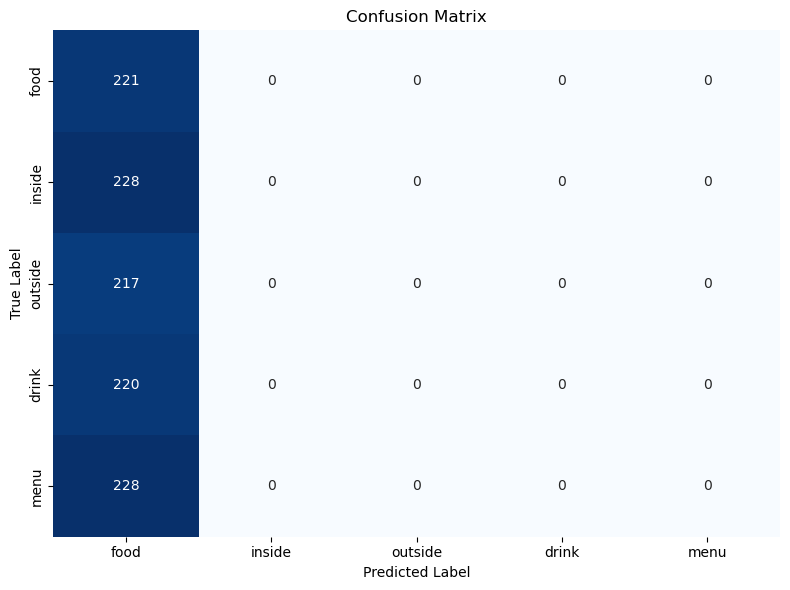

Confusion Matrix for test data
Confusion Matrix:
          food  inside  outside  drink  menu
food       54       0        0      0     0
inside     52       0        0      0     0
outside    58       0        0      0     0
drink      58       0        0      0     0
menu       57       0        0      0     0


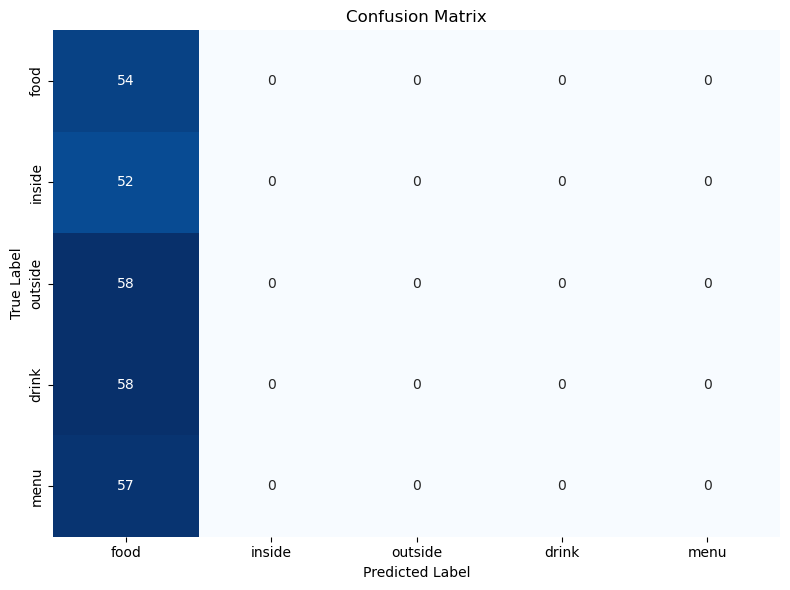

ROC for train data


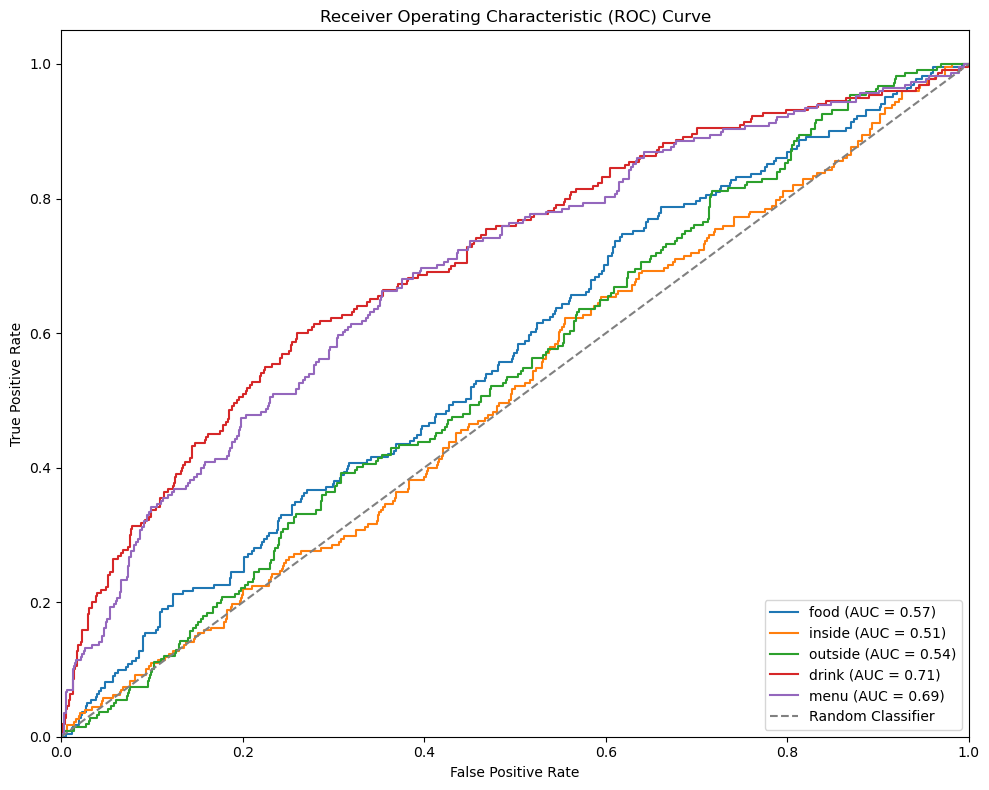

AUC for class food: 0.57
AUC for class inside: 0.51
AUC for class outside: 0.54
AUC for class drink: 0.71
AUC for class menu: 0.69
ROC for test data


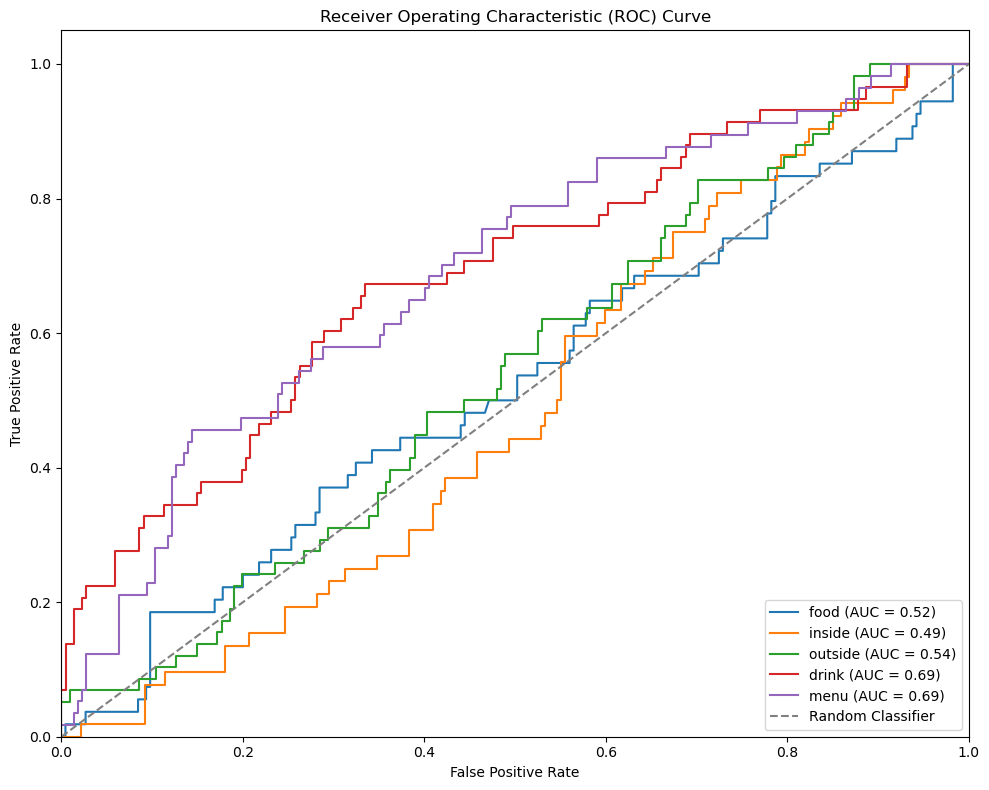

AUC for class food: 0.52
AUC for class inside: 0.49
AUC for class outside: 0.54
AUC for class drink: 0.69
AUC for class menu: 0.69


In [127]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers of VGG16 (no fine-tuning)
base_model.trainable = False  

# Build the custom model
image_input = Input(shape=(224, 224, 3))
x = base_model(image_input, training=False)  # Use training=False to keep frozen layers stable
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
final_output = Dense(5, activation='softmax')(x)

model = Model(inputs=image_input, outputs=final_output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define the ImageDataGenerator (without augmentation for training data)
train_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

# Apply the generator to your training and testing data
train_generator = train_datagen.flow(x_train, y_train, batch_size=32)
validation_generator = test_datagen.flow(x_test, y_test, batch_size=32)

start_time = time.time()
# Train the model (only the custom dense layers will be updated)
model.fit(train_generator, epochs=10, validation_data=validation_generator)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Predict the labels for the training set
y_train_pred = model.predict(x_train)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)

# Predict the labels for the test set
y_test_pred = model.predict(x_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
print("Confusion Matrix for train data")
plot_confusion_matrix(y_train, y_train_pred_labels)

print("Confusion Matrix for test data")
plot_confusion_matrix(y_test, y_test_pred_labels)

# ROC Curve
print("ROC for train data")
plot_roc_curve(y_train, y_train_pred)

print("ROC for test data")
plot_roc_curve(y_test, y_test_pred)


lime

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-233.55799865722656..1.0].


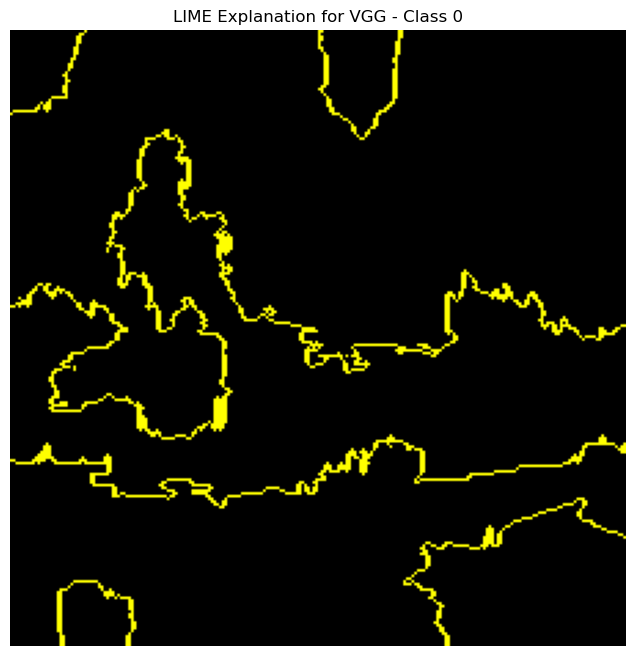

In [129]:
explain_with_lime(model, x_test[0], model_type="vgg")

vgg freeze all layears with image augumentation

C:\Users\Gaurav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.2069 - loss: 2.4304 - val_accuracy: 0.1971 - val_loss: 1.6325
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.2187 - loss: 2.0966 - val_accuracy: 0.1864 - val_loss: 1.6447
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.2125 - loss: 2.0133 - val_accuracy: 0.1756 - val_loss: 1.6331
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.2046 - loss: 1.9147 - val_accuracy: 0.2007 - val_loss: 1.6223
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.1932 - loss: 1.8939 - val_accuracy: 0.1935 - val_loss: 1.6249
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.2055 - loss: 1.7781 - val_accuracy: 0.1720 - val_loss: 1.6201
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.1980 - loss: 1.8237 - val_accuracy: 0.1613 - val_loss: 1.6214
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.1723 - loss: 1.8235 - val_accuracy: 0.2007 - val_loss:

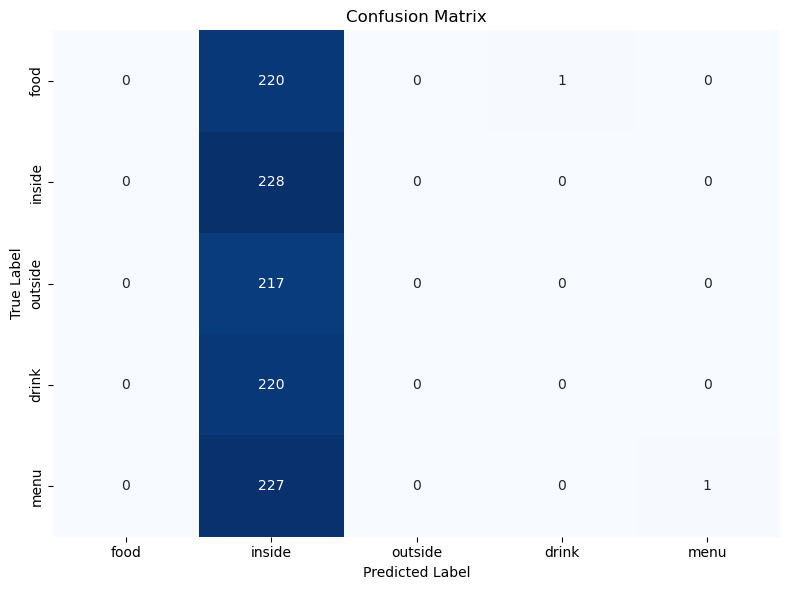

Confusion Matrix for test data
Confusion Matrix:
          food  inside  outside  drink  menu
food        0      54        0      0     0
inside      0      52        0      0     0
outside     0      58        0      0     0
drink       0      58        0      0     0
menu        0      57        0      0     0


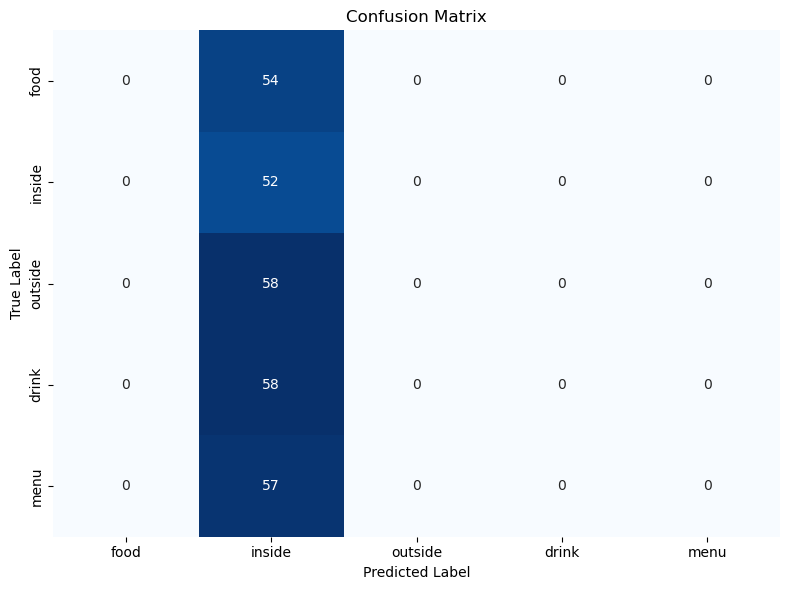

ROC for train data


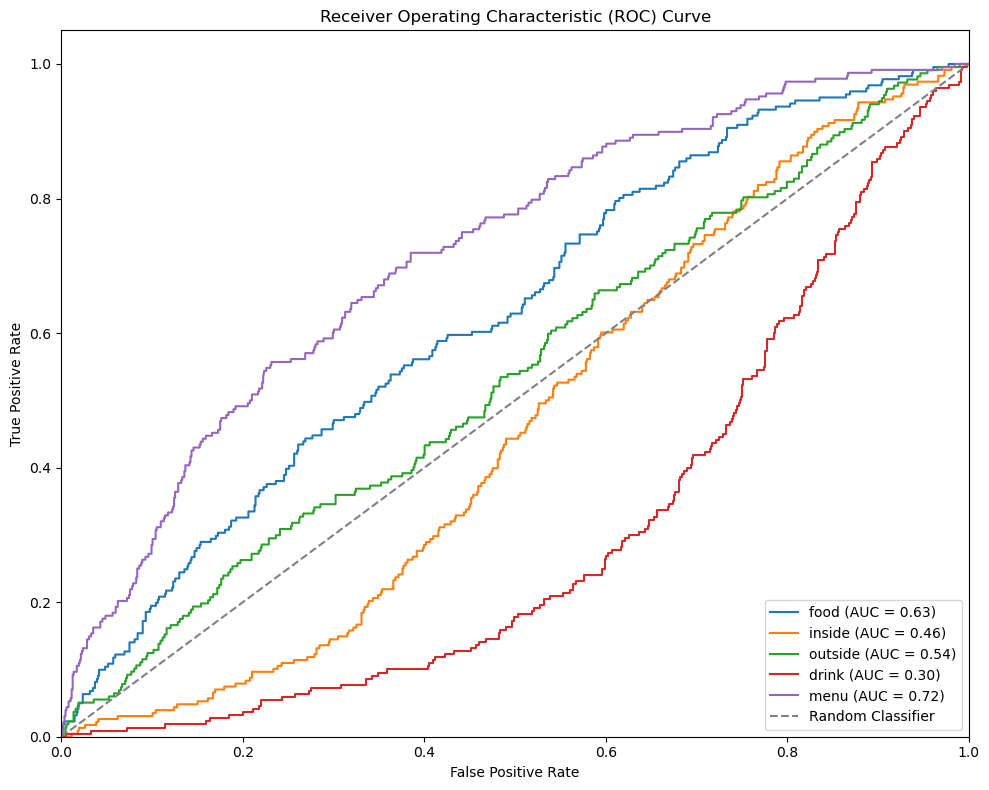

AUC for class food: 0.63
AUC for class inside: 0.46
AUC for class outside: 0.54
AUC for class drink: 0.30
AUC for class menu: 0.72
ROC for test data


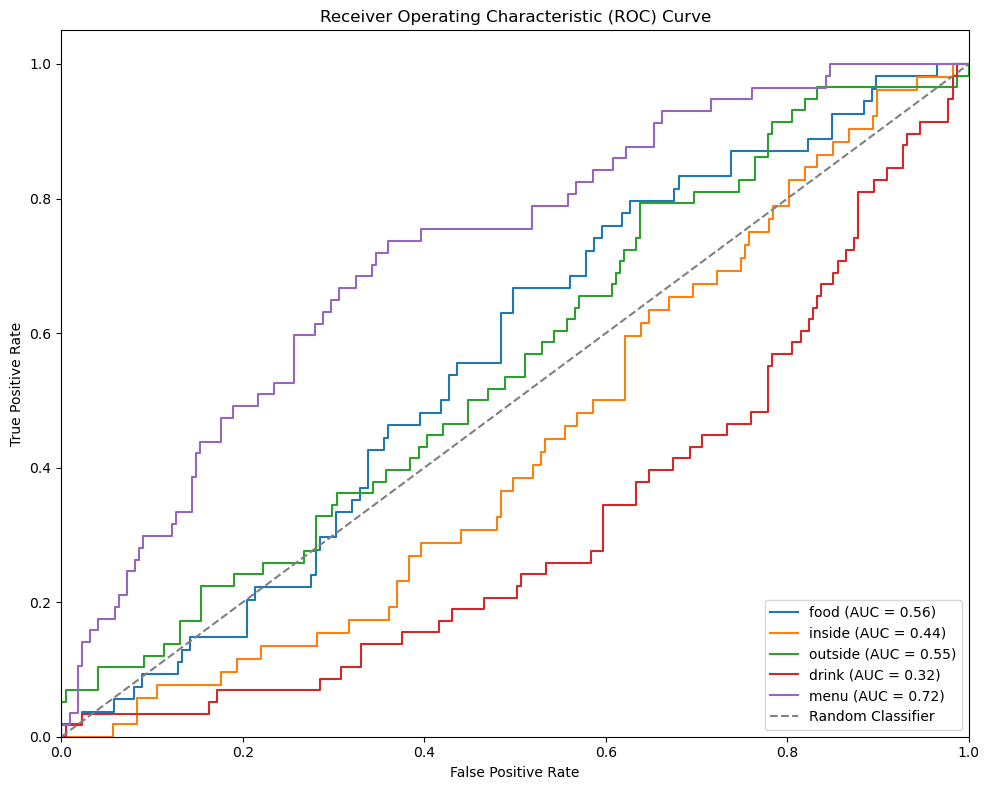

AUC for class food: 0.56
AUC for class inside: 0.44
AUC for class outside: 0.55
AUC for class drink: 0.32
AUC for class menu: 0.72


In [131]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers of VGG16
base_model.trainable = False  

# Build the custom model
image_input = Input(shape=(224, 224, 3))
x = base_model(image_input, training=False)  # Keep batch norm layers in inference mode
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
final_output = Dense(5, activation='softmax')(x)

model = Model(inputs=image_input, outputs=final_output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define the ImageDataGenerator with augmentation for the training data
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for the test data
test_datagen = ImageDataGenerator()

# Apply augmentation to training data
train_generator = train_datagen.flow(x_train, y_train, batch_size=32)
validation_generator = test_datagen.flow(x_test, y_test, batch_size=32)

start_time = time.time()
# Train the model (only the custom dense layers will be updated)
model.fit(train_generator, epochs=10, validation_data=validation_generator)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Predict the labels for the training set
y_train_pred = model.predict(x_train)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)

# Predict the labels for the test set
y_test_pred = model.predict(x_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
print("Confusion Matrix for train data")
plot_confusion_matrix(y_train, y_train_pred_labels)

print("Confusion Matrix for test data")
plot_confusion_matrix(y_test, y_test_pred_labels)

# ROC Curve
print("ROC for train data")
plot_roc_curve(y_train, y_train_pred)

print("ROC for test data")
plot_roc_curve(y_test, y_test_pred)


lime

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-351.29901123046875..1.0].


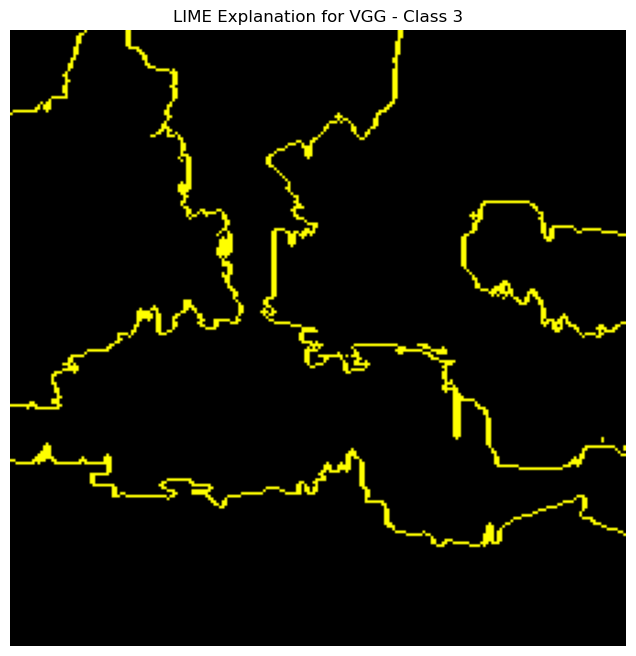

In [133]:
explain_with_lime(model, x_test[0], model_type="vgg")

vgg with some unfreeze layers and image augumentation

C:\Users\Gaurav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2143 - loss: 1.8468 - val_accuracy: 0.1900 - val_loss: 1.6092
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.2016 - loss: 1.6098 - val_accuracy: 0.1864 - val_loss: 1.6097
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.1752 - loss: 1.6099 - val_accuracy: 0.1864 - val_loss: 1.6098
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.2072 - loss: 1.6096 - val_accuracy: 0.1864 - val_loss: 1.6096
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.2057 - loss: 1.6095 - val_accuracy: 0.1864 - val_loss: 1.6096
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.2009 - loss: 1.6095 - val_accuracy: 0.1864 - val_loss: 1.6096
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.1874 - loss: 1.6095 - val_accuracy: 0.1864 - val_loss: 1.6096
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.1901 - loss: 1.6094 - val_accuracy: 0.1864 - val_loss:

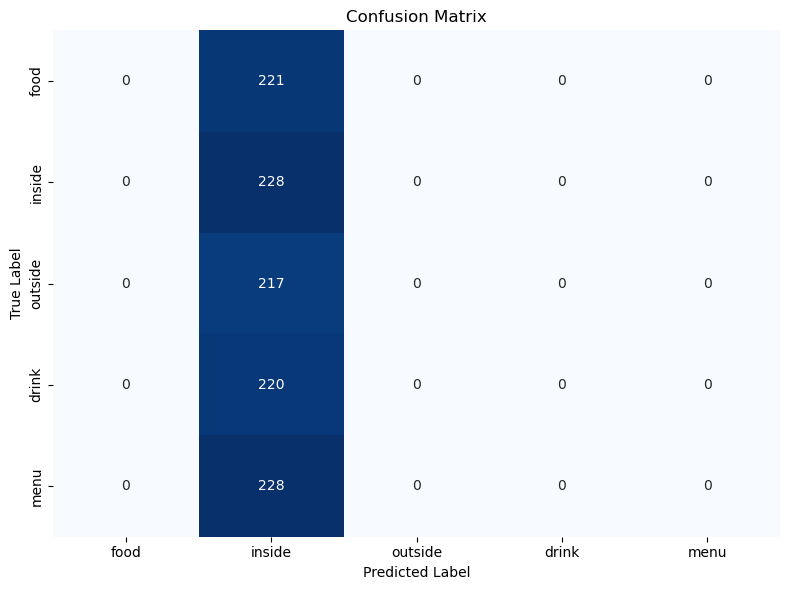

Confusion Matrix for test data
Confusion Matrix:
          food  inside  outside  drink  menu
food        0      54        0      0     0
inside      0      52        0      0     0
outside     0      58        0      0     0
drink       0      58        0      0     0
menu        0      57        0      0     0


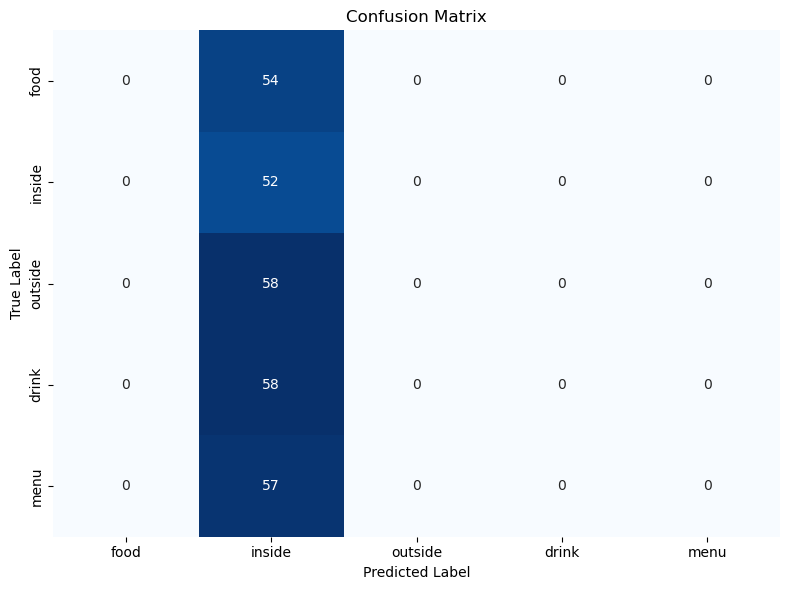

ROC for train data


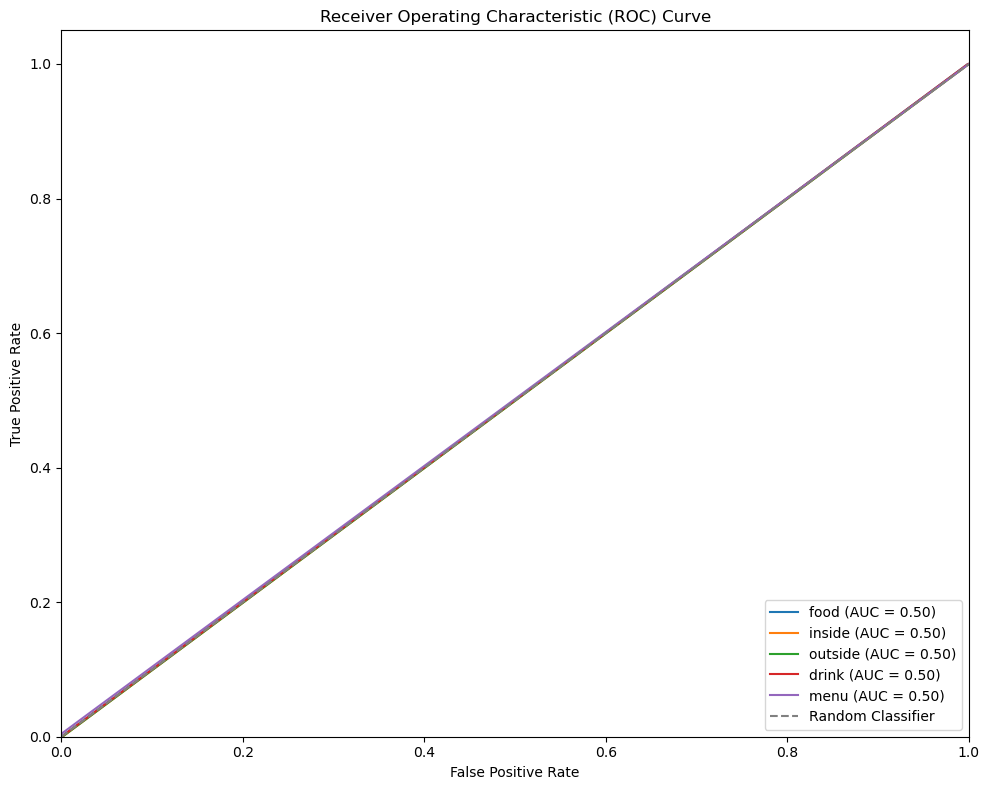

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.50
AUC for class drink: 0.50
AUC for class menu: 0.50
ROC for test data


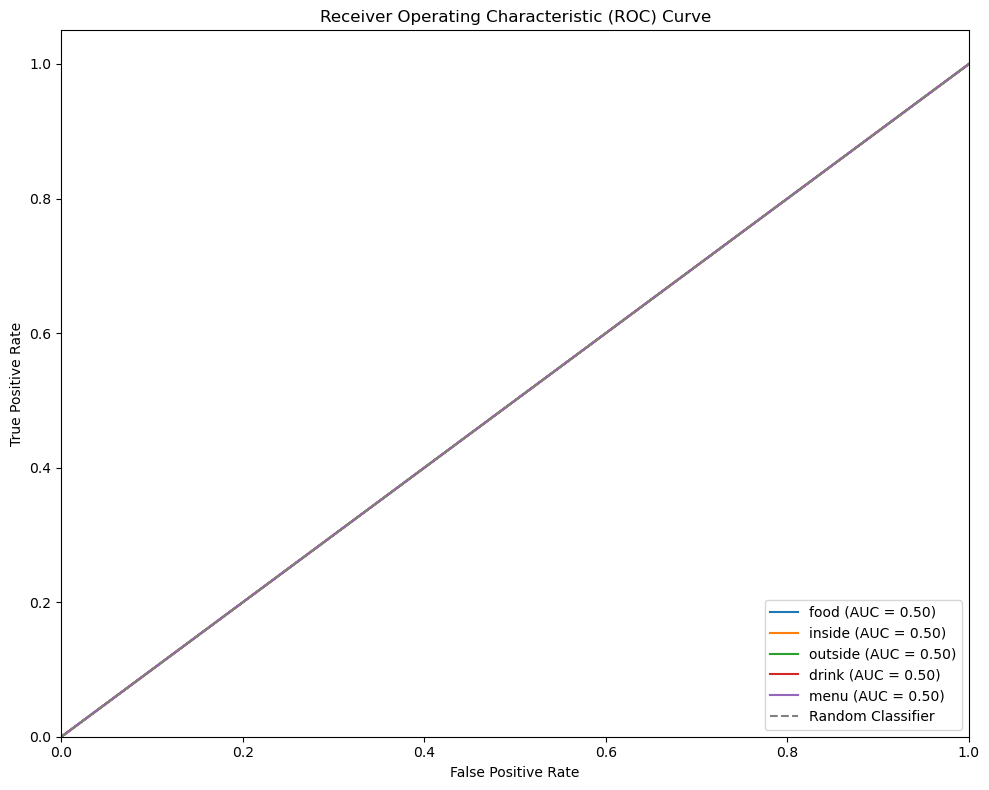

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.50
AUC for class drink: 0.50
AUC for class menu: 0.50


In [135]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the last few layers of the base model and freeze the rest
for layer in base_model.layers[:-4]:  # Freeze all layers except the last 4
    layer.trainable = False

# Build the custom model
image_input = Input(shape=(224, 224, 3))
x = base_model(image_input, training=True)  # Training=True to fine-tune the unfrozen layers
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
final_output = Dense(5, activation='softmax')(x)

model = Model(inputs=image_input, outputs=final_output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define the ImageDataGenerator with augmentation for the training data
train_datagen = ImageDataGenerator(
    rotation_range=40,  # Random rotation between 0 and 40 degrees
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shearing transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Filling mode for newly created pixels
)

# No augmentation for the test data, just use it as it is
test_datagen = ImageDataGenerator()

# Apply the augmentation to your training and testing data
train_generator = train_datagen.flow(x_train, y_train, batch_size=32)
validation_generator = test_datagen.flow(x_test, y_test, batch_size=32)

start_time = time.time()
# Fine-tune the model with augmented images
model.fit(train_generator, epochs=10, validation_data=validation_generator)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Predict the labels for the training set
y_train_pred = model.predict(x_train)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)

# Predict the labels for the test set
y_test_pred = model.predict(x_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
print("Confusion Matrix for train data")
plot_confusion_matrix(y_train, y_train_pred_labels)

print("Confusion Matrix for test data")
plot_confusion_matrix(y_test, y_test_pred_labels)

# ROC Curve
print("ROC for train data")
plot_roc_curve(y_train, y_train_pred)

print("ROC for test data")
plot_roc_curve(y_test, y_test_pred)


lime

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-474.97900390625..1.0].


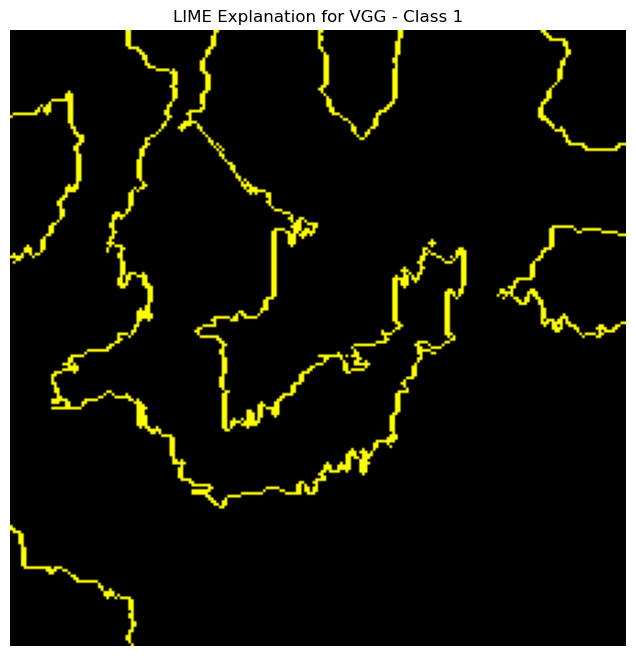

In [137]:
explain_with_lime(model, x_test[0], model_type="vgg")

unfreeze all layers

Epoch 1/10


C:\Users\Gaurav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 187s 5s/step - accuracy: 0.1772 - loss: 1.8138 - val_accuracy: 0.1864 - val_loss: 1.6114
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.1962 - loss: 1.6094 - val_accuracy: 0.2079 - val_loss: 1.6094
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.2062 - loss: 1.6095 - val_accuracy: 0.2079 - val_loss: 1.6094
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.1854 - loss: 1.6100 - val_accuracy: 0.2079 - val_loss: 1.6095
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.2025 - loss: 1.6095 - val_accuracy: 0.1864 - val_loss: 1.6096
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.1993 - loss: 1.6095 - val_accuracy: 0.1864 - val_loss: 1.6096
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.1967 - loss: 1.6095 - val_accuracy: 0.1864 - val_loss: 1.6096
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.2044 - loss: 1.6094 - val_accuracy: 0.1864 - val_loss: 1.

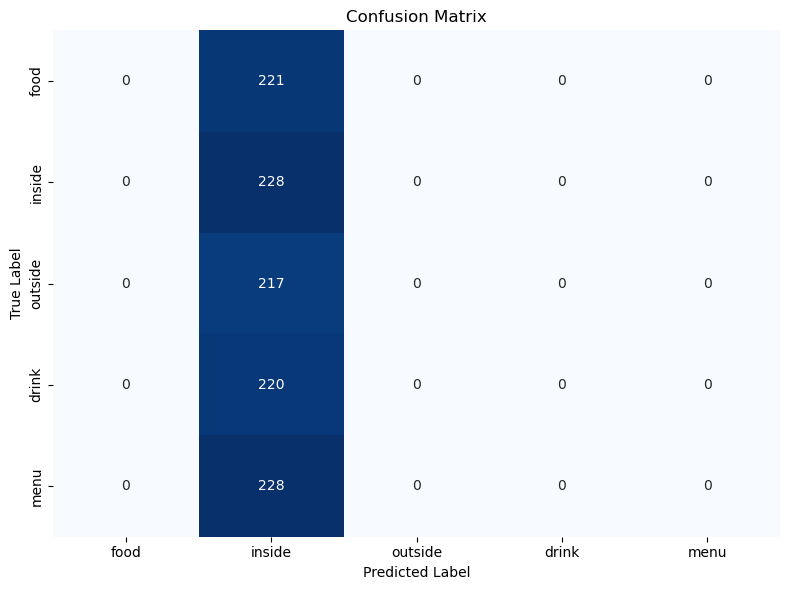

Confusion Matrix for test data
Confusion Matrix:
          food  inside  outside  drink  menu
food        0      54        0      0     0
inside      0      52        0      0     0
outside     0      58        0      0     0
drink       0      58        0      0     0
menu        0      57        0      0     0


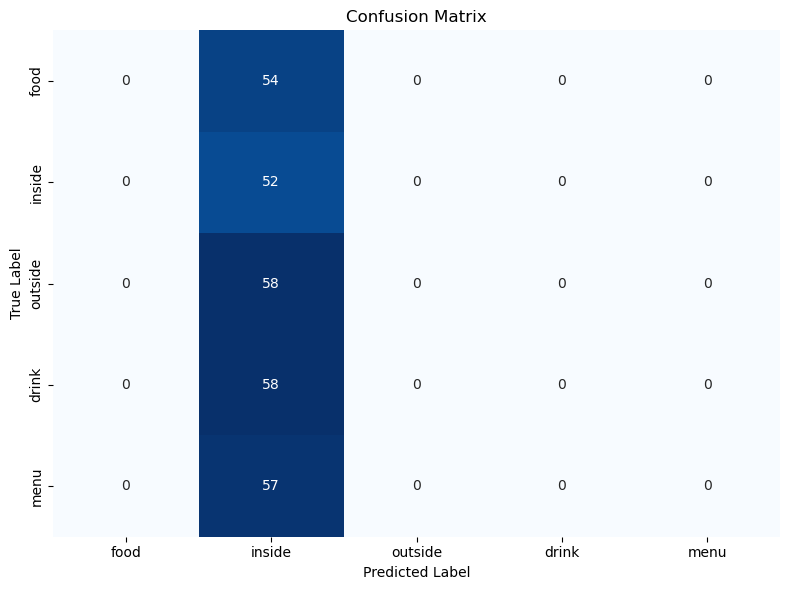

ROC for train data


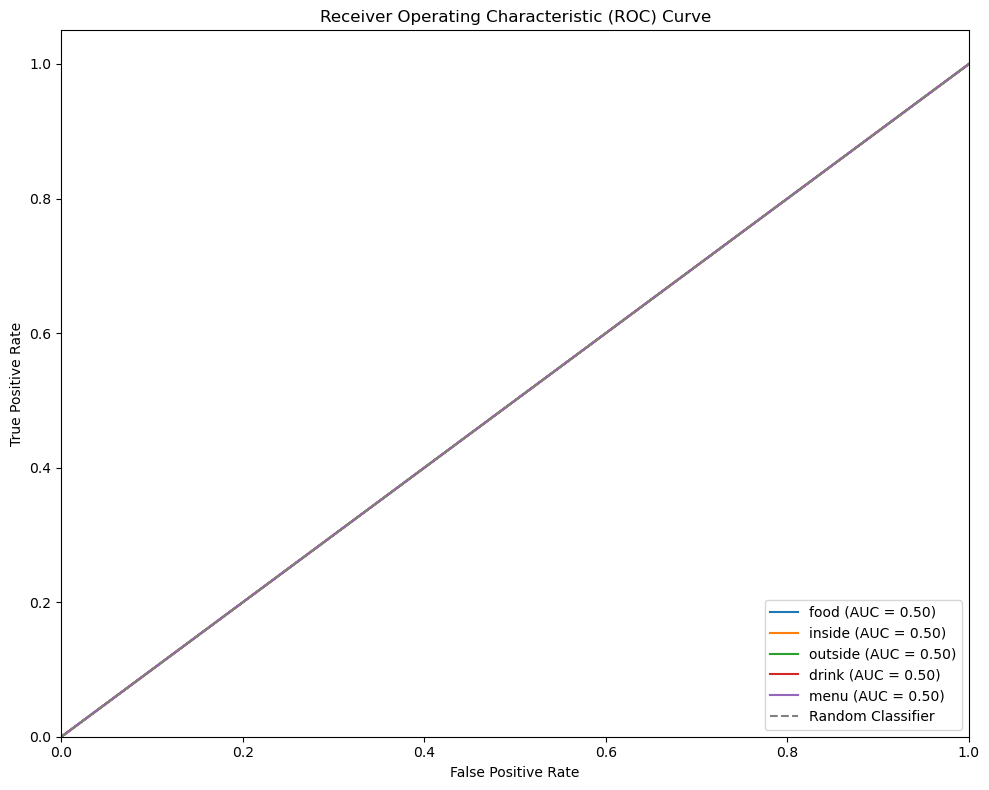

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.50
AUC for class drink: 0.50
AUC for class menu: 0.50
ROC for test data


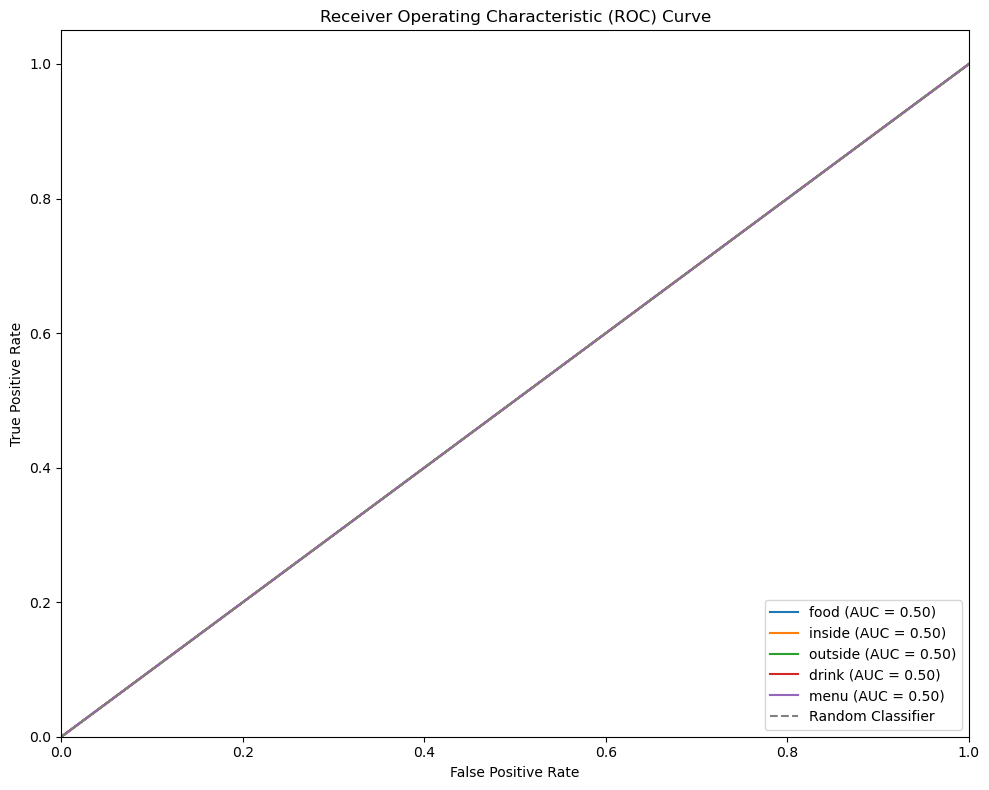

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.50
AUC for class drink: 0.50
AUC for class menu: 0.50


In [139]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # No freezing, fine-tune the entire model

# Build the custom model
image_input = Input(shape=(224, 224, 3))
x = base_model(image_input, training=True)  # Training=True to fine-tune
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
final_output = Dense(5, activation='softmax')(x)

model = Model(inputs=image_input, outputs=final_output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define the ImageDataGenerator (without augmentation for the training data)
train_datagen = ImageDataGenerator()

# No augmentation for the test data, just use it as it is
test_datagen = ImageDataGenerator()

# Apply the generator to your training and testing data
train_generator = train_datagen.flow(x_train, y_train, batch_size=32)
validation_generator = test_datagen.flow(x_test, y_test, batch_size=32)

start_time = time.time()
# Fine-tune the model with the original images (no augmentation)
model.fit(train_generator, epochs=10, validation_data=validation_generator)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Predict the labels for the training set
y_train_pred = model.predict(x_train)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)

# Predict the labels for the test set
y_test_pred = model.predict(x_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
print("Confusion Matrix for train data")
plot_confusion_matrix(y_train, y_train_pred_labels)

print("Confusion Matrix for test data")
plot_confusion_matrix(y_test, y_test_pred_labels)

# ROC Curve
print("ROC for train data")
plot_roc_curve(y_train, y_train_pred)

print("ROC for test data")
plot_roc_curve(y_test, y_test_pred)


lime

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-598.6589965820312..1.0].


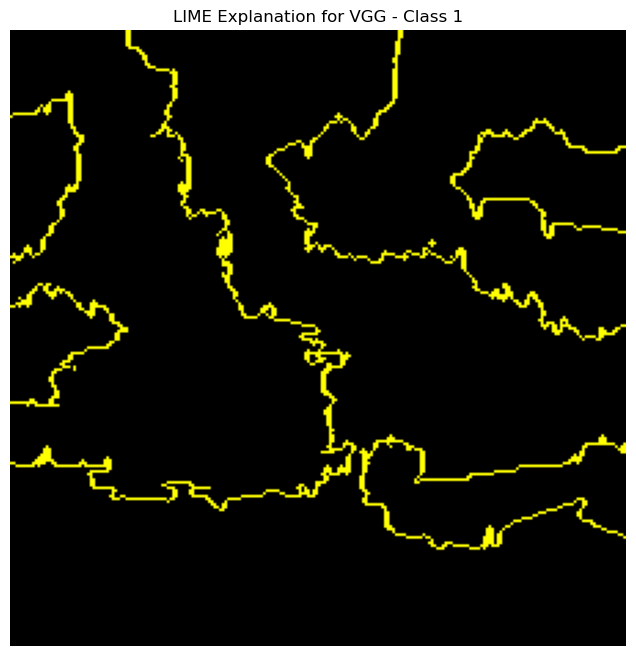

In [141]:
explain_with_lime(model, x_test[0], model_type="vgg")

unfreeze all layers and image augumentation

C:\Users\Gaurav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 194s 5s/step - accuracy: 0.1737 - loss: 1.8172 - val_accuracy: 0.2043 - val_loss: 1.6118
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 187s 5s/step - accuracy: 0.1833 - loss: 1.6184 - val_accuracy: 0.1864 - val_loss: 1.6095
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 187s 5s/step - accuracy: 0.2299 - loss: 1.6095 - val_accuracy: 0.1864 - val_loss: 1.6095
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 188s 5s/step - accuracy: 0.2049 - loss: 1.6092 - val_accuracy: 0.1864 - val_loss: 1.6095
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.1940 - loss: 1.6097 - val_accuracy: 0.2079 - val_loss: 1.6094
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.1941 - loss: 1.6095 - val_accuracy: 0.2079 - val_loss: 1.6094
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.2147 - loss: 1.6094 - val_accuracy: 0.2043 - val_loss: 1.6094
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 188s 5s/step - accuracy: 0.1984 - loss: 1.6095 - val_accuracy: 0.2043 - v

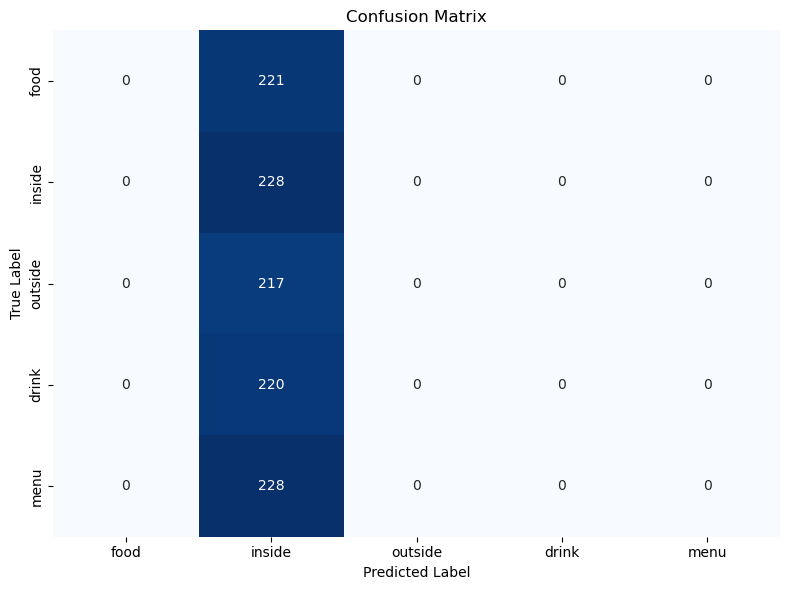

Confusion Matrix for test data
Confusion Matrix:
          food  inside  outside  drink  menu
food        0      54        0      0     0
inside      0      52        0      0     0
outside     0      58        0      0     0
drink       0      58        0      0     0
menu        0      57        0      0     0


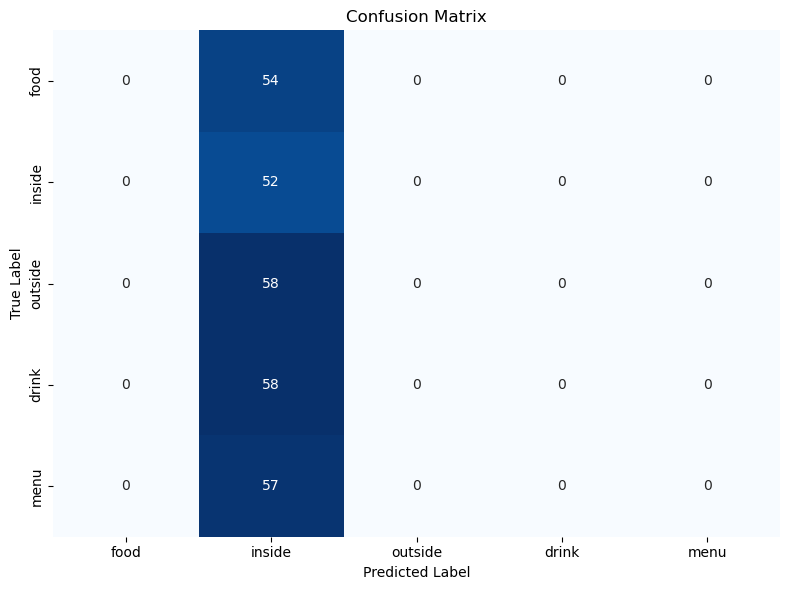

ROC for train data


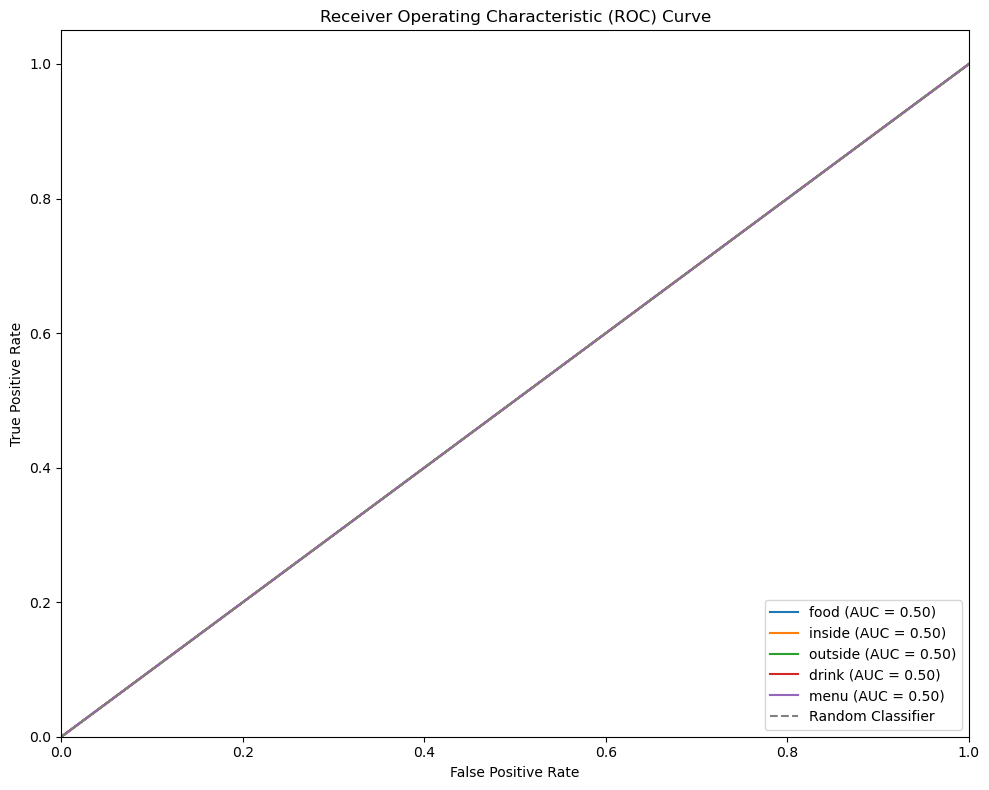

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.50
AUC for class drink: 0.50
AUC for class menu: 0.50
ROC for test data


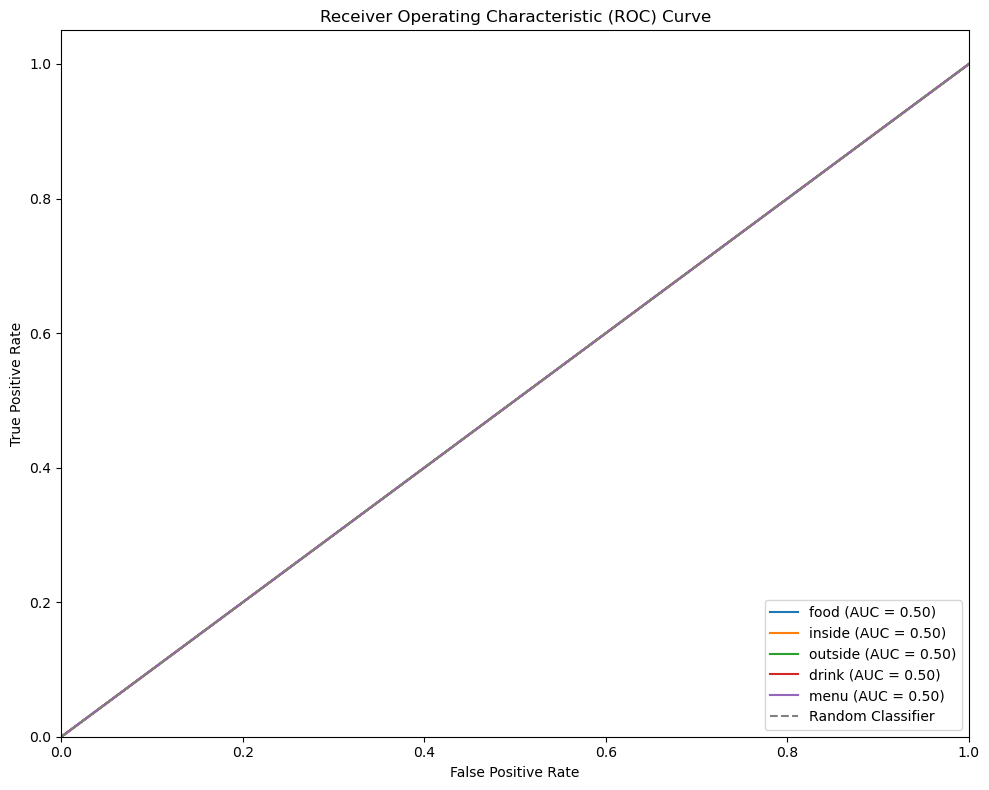

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.50
AUC for class drink: 0.50
AUC for class menu: 0.50


In [143]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Load VGG16 without top layers (include_top=False) for fine-tuning
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# No freezing of any layers (all layers are trainable)
base_model.trainable = True

# Build the custom model
image_input = Input(shape=(224, 224, 3))
x = base_model(image_input, training=True)  # Training=True to ensure all layers are trainable
x = GlobalAveragePooling2D()(x)  # Pooling the feature map output from the base model
x = Dense(256, activation='relu')(x)  # Fully connected layer
x = Dropout(0.5)(x)  # Dropout to prevent overfitting
x = Dense(128, activation='relu')(x)  # Another fully connected layer
x = Dropout(0.3)(x)  # Dropout
final_output = Dense(5, activation='softmax')(x)  # Output layer with softmax for multi-class classification

model = Model(inputs=image_input, outputs=final_output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define the ImageDataGenerator with augmentation for the training data
train_datagen = ImageDataGenerator(
    rotation_range=40,  # Random rotation between 0 and 40 degrees
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shearing transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Filling mode for newly created pixels
)

# No augmentation for the test data, just use it as it is
test_datagen = ImageDataGenerator()

# Apply the augmentation to your training and testing data
train_generator = train_datagen.flow(x_train, y_train, batch_size=32)
validation_generator = test_datagen.flow(x_test, y_test, batch_size=32)

start_time = time.time()
# Fine-tune the model with augmented images
model.fit(train_generator, epochs=10, validation_data=validation_generator)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Predict the labels for the training set
y_train_pred = model.predict(x_train)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)

# Predict the labels for the test set
y_test_pred = model.predict(x_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
print("Confusion Matrix for train data")
plot_confusion_matrix(y_train, y_train_pred_labels)

print("Confusion Matrix for test data")
plot_confusion_matrix(y_test, y_test_pred_labels)

# ROC Curve
print("ROC for train data")
plot_roc_curve(y_train, y_train_pred)

print("ROC for test data")
plot_roc_curve(y_test, y_test_pred)

In [144]:
y_test[0]

2

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-722.3389892578125..1.0].


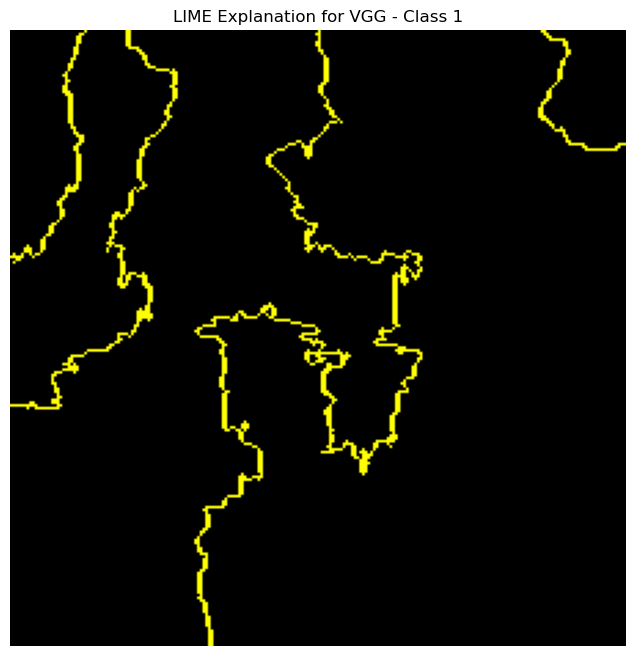

In [145]:
explain_with_lime(model, x_test[0], model_type="vgg")

vss with unfreeze all layers and gaussian blur

In [147]:
!pip install opencv-python

Epoch 1/10


C:\Users\Gaurav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 191s 5s/step - accuracy: 0.1930 - loss: 1.7539 - val_accuracy: 0.2079 - val_loss: 1.6093
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 187s 5s/step - accuracy: 0.2200 - loss: 1.6095 - val_accuracy: 0.2079 - val_loss: 1.6093
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 187s 5s/step - accuracy: 0.1966 - loss: 1.6094 - val_accuracy: 0.1900 - val_loss: 1.6095
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.2007 - loss: 1.6099 - val_accuracy: 0.1864 - val_loss: 1.6095
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.1958 - loss: 1.6094 - val_accuracy: 0.1864 - val_loss: 1.6095
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.1940 - loss: 1.6094 - val_accuracy: 0.1864 - val_loss: 1.6095
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.1869 - loss: 1.6096 - val_accuracy: 0.2043 - val_loss: 1.6095
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.1932 - loss: 1.6094 - val_accuracy: 0.1864 - val_loss: 1.

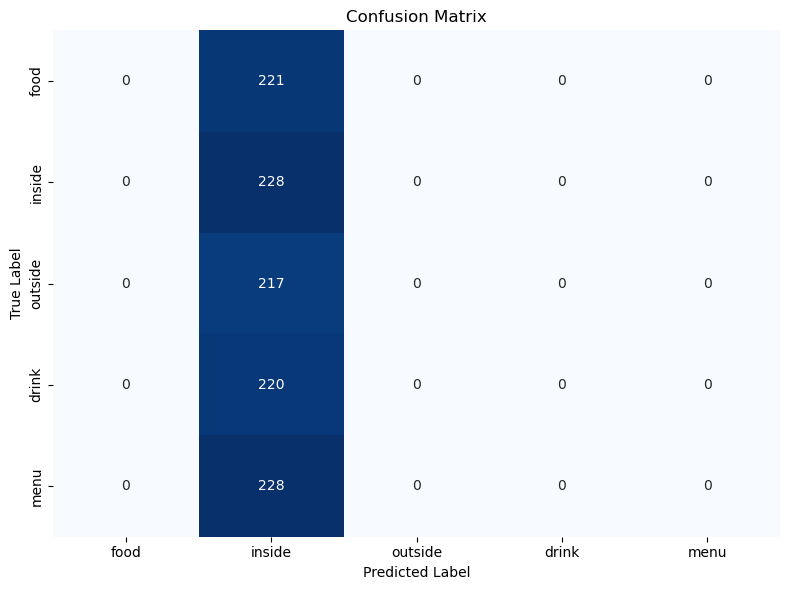

Confusion Matrix for test data
Confusion Matrix:
          food  inside  outside  drink  menu
food        0      54        0      0     0
inside      0      52        0      0     0
outside     0      58        0      0     0
drink       0      58        0      0     0
menu        0      57        0      0     0


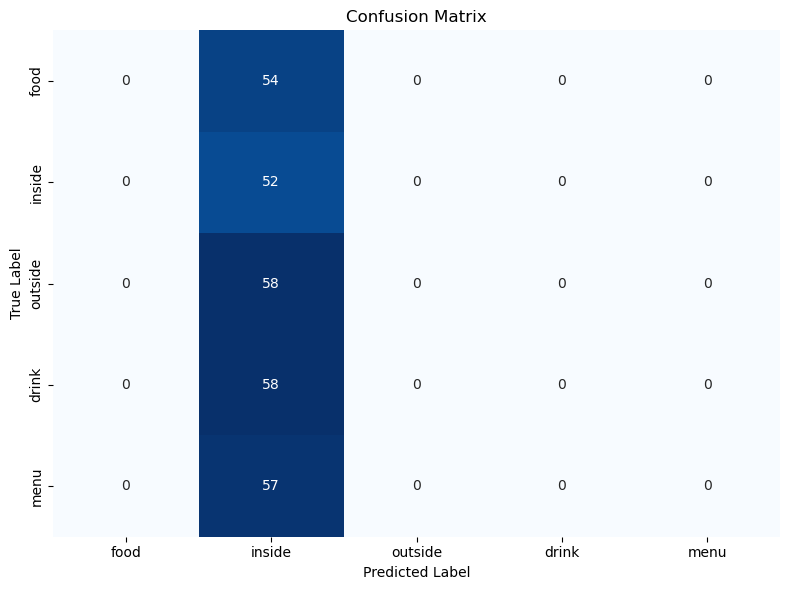

ROC for train data


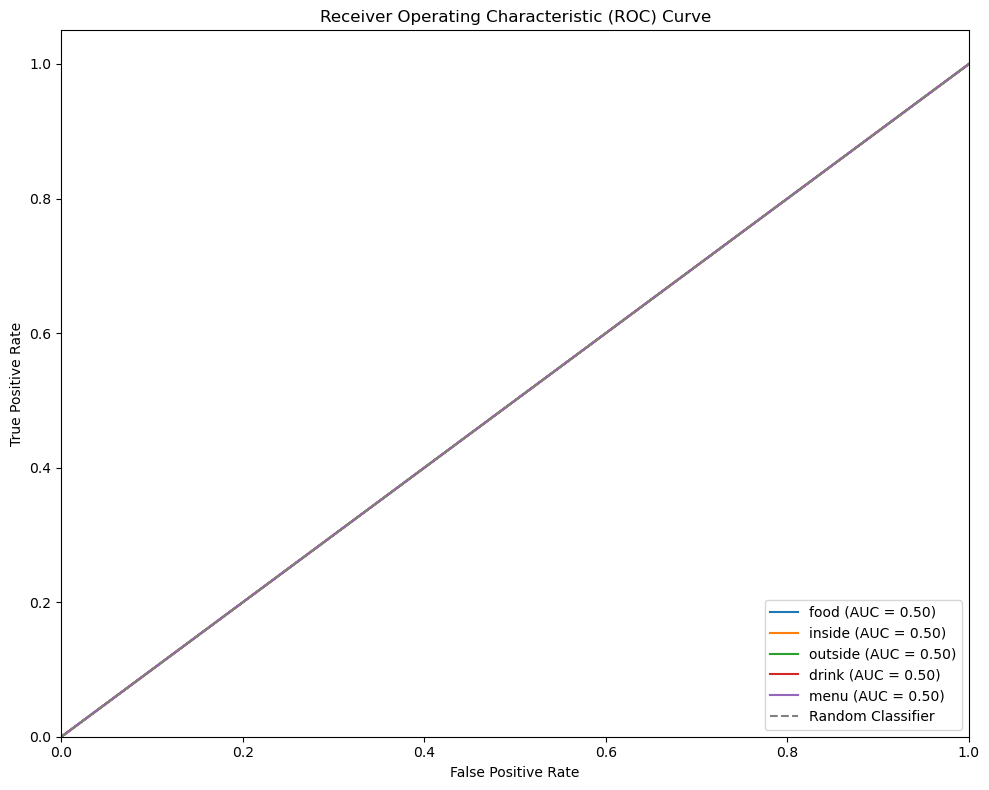

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.50
AUC for class drink: 0.50
AUC for class menu: 0.50
ROC for test data


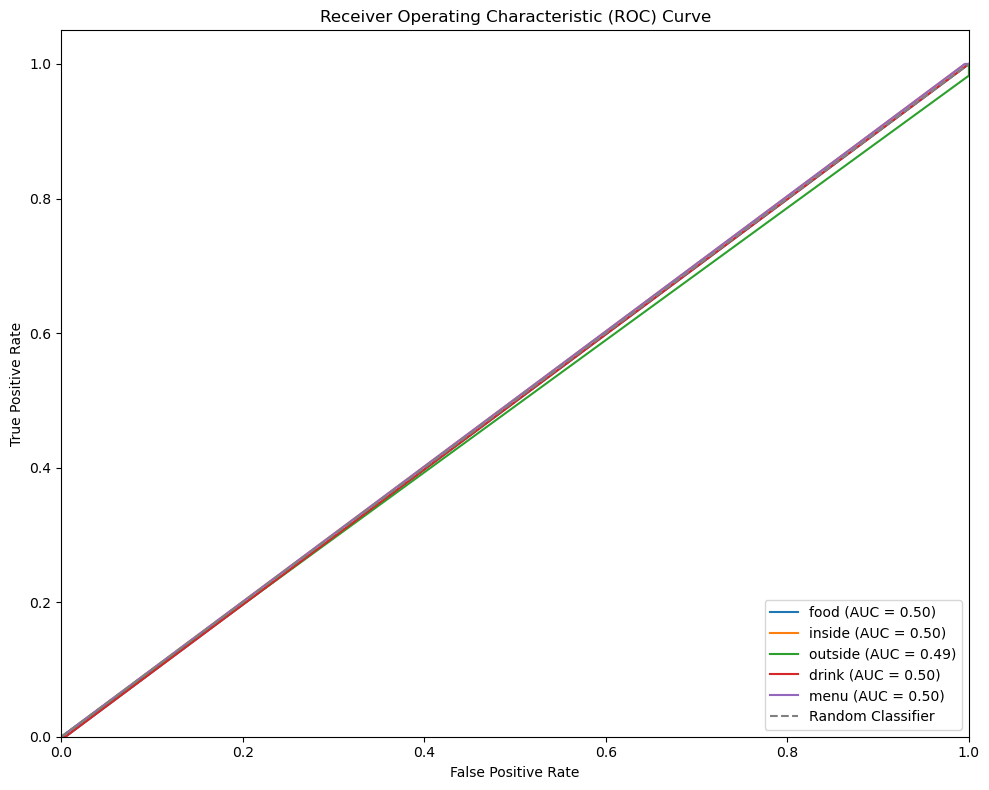

AUC for class food: 0.50
AUC for class inside: 0.50
AUC for class outside: 0.49
AUC for class drink: 0.50
AUC for class menu: 0.50


In [148]:
import tensorflow as tf
import numpy as np
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Function to apply Gaussian Blur
def apply_gaussian_blur(image):
    """
    Applies Gaussian blur to an image.
    
    Parameters:
    - image: Input image in NumPy array format.
    
    Returns:
    - Blurred image.
    """
    image = np.array(image)  # Convert to NumPy array (if not already)
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)  # Kernel size (5,5), standard deviation 0
    return blurred_image

# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # Fine-tune the entire model

# Build the custom model
image_input = Input(shape=(224, 224, 3))
x = base_model(image_input, training=True)  # Training=True to fine-tune
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
final_output = Dense(5, activation='softmax')(x)

model = Model(inputs=image_input, outputs=final_output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define ImageDataGenerator with Gaussian Blur
train_datagen = ImageDataGenerator(preprocessing_function=apply_gaussian_blur)
test_datagen = ImageDataGenerator(preprocessing_function=apply_gaussian_blur)

# Apply the generator to training and testing data
train_generator = train_datagen.flow(x_train, y_train, batch_size=32)
validation_generator = test_datagen.flow(x_test, y_test, batch_size=32)

start_time = time.time()
# Fine-tune the model
model.fit(train_generator, epochs=10, validation_data=validation_generator)
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Predict labels for train and test data
y_train_pred = model.predict(x_train)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)

y_test_pred = model.predict(x_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
print("Confusion Matrix for train data")
plot_confusion_matrix(y_train, y_train_pred_labels)

print("Confusion Matrix for test data")
plot_confusion_matrix(y_test, y_test_pred_labels)

# ROC Curve
print("ROC for train data")
plot_roc_curve(y_train, y_train_pred)

print("ROC for test data")
plot_roc_curve(y_test, y_test_pred)


lime

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-846.0189819335938..1.0].


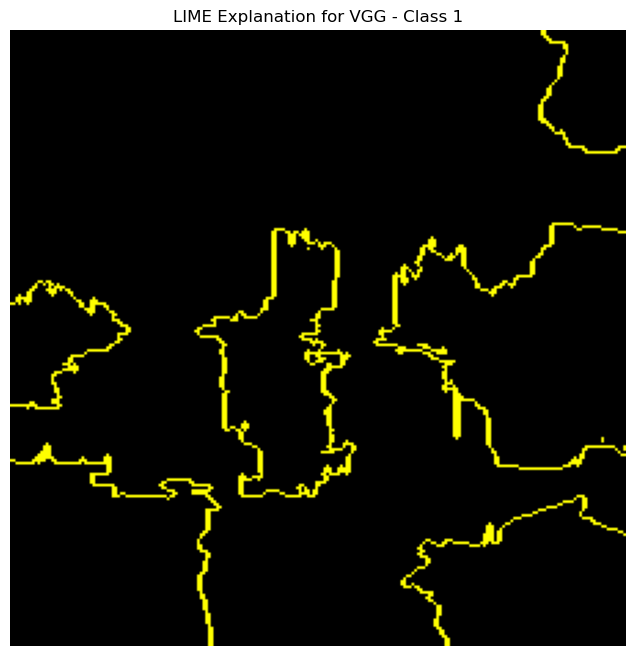

In [150]:
explain_with_lime(model, x_test[0], model_type="vgg")